# Goal: understand the dataset of clusters created to use for training + inference on VAE

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
col = pd.read_pickle('/Volumes/easystore/proton-kaon/clusters/col.pkl')
ind = pd.read_pickle('/Volumes/easystore/proton-kaon/clusters/ind.pkl')

In [3]:
col.columns

Index(['run', 'subrun', 'event', 'cluster_idx_ind', 'cluster_idx_col',
       'd_min_c', 'd_max_c', 'd_min_r', 'd_max_r', 'd_h', 'match_score',
       'event_idx', 'file_path', 'event_index', 'particle_type', 'plane',
       'cluster_idx', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row',
       'bbox_max_col', 'width', 'height', 'image_intensity', 'column_maxes',
       'p', 'm', 'beamline_mass', 'trkrr', 'trkdedx', 'chi_squared_kaon',
       'chi_squared_proton', 'particle_hypothesis'],
      dtype='str')

In [3]:
len(ind), len(col)

(23723, 23723)

In [4]:
len(ind[ind['particle_type'] == 'kaon']), len(ind[ind['particle_type'] == 'proton'])

(11433, 12290)

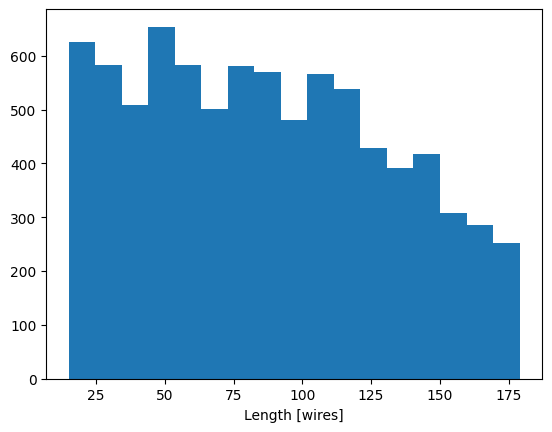

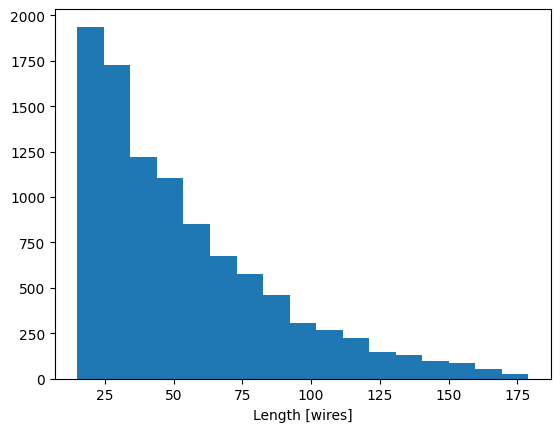

In [5]:
bins = np.linspace(15, 179, 18)
plt.hist(col[col['particle_type'] == 'kaon']['height'], bins=bins); plt.xlabel('Length [wires]'); plt.show()
plt.hist(col[col['particle_type'] == 'proton']['height'], bins=bins); plt.xlabel('Length [wires]'); plt.show()

In [6]:
print('how much date is removed by the 50 wire cut? clusters wires > 50')

for name, df in {"collection": col, "induction": ind}.items():
    print(name)
    for particle in ["kaon", "proton"]:
        pct = df.loc[df["particle_type"] == particle, "height"].gt(50).mean() * 100
        print(f"  {particle}: {pct:.2f}%")

how much date is removed by the 50 wire cut? clusters wires > 50
collection
  kaon: 53.32%
  proton: 34.29%
induction
  kaon: 49.77%
  proton: 34.11%


In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from src.cuts import image_cuts
from src.images import cut_start, pad_image

# Raw inputs used to build the saved tensor
col = pd.read_pickle("/Volumes/easystore/proton-kaon/clusters/col.pkl")
ind = pd.read_pickle("/Volumes/easystore/proton-kaon/clusters/ind.pkl")
col, ind = image_cuts(col, ind)

p_c_list = col.loc[col["particle_type"] == "proton", "image_intensity"].tolist()

# Saved processed tensor: shape (N, 2, 48, 48)
out = "/Volumes/easystore/proton-kaon/images/pk_48x48_log1p.pt"
data = torch.load(out, map_location="cpu")
p = data["p"].numpy()
p_col = p[:, 0]   # proton collection channel

assert len(p_c_list) == len(p_col)

def preprocess_before_log(img):
    end = cut_start(img, target=50)
    padded = pad_image(end, target_wh=(1502, 51))
    t = torch.from_numpy(padded).float().unsqueeze(0).unsqueeze(0)
    down_raw = F.interpolate(t, size=(48, 48), mode="bilinear", align_corners=False)
    return end, padded, down_raw.squeeze().numpy()

def prominence(profile):
    if profile.size < 2:
        return np.nan
    top2 = np.partition(profile, -2)[-2:]
    return top2[-1] / max(top2[-2], 1e-12)

def width_halfmax(profile):
    return int((profile >= 0.5 * profile.max()).sum())

sample_n = min(100, len(p_c_list))

peak_same = []
peak_within_1 = []
prom_raw = []
prom_log = []
width_raw = []
width_log = []

for i in range(sample_n):
    _, _, down_raw = preprocess_before_log(p_c_list[i])
    down_log = p_col[i]  # already log1p(down_raw)

    prof_raw = down_raw.sum(axis=0)
    prof_log = down_log.sum(axis=0)

    peak_raw = int(np.argmax(prof_raw))
    peak_log = int(np.argmax(prof_log))

    peak_same.append(peak_raw == peak_log)
    peak_within_1.append(abs(peak_raw - peak_log) <= 1)

    prom_raw.append(prominence(prof_raw))
    prom_log.append(prominence(prof_log))

    width_raw.append(width_halfmax(prof_raw))
    width_log.append(width_halfmax(prof_log))

print(f"Exact peak-column agreement after log: {np.mean(peak_same):.2%}")
print(f"Peak-column agreement within 1 bin:    {np.mean(peak_within_1):.2%}")
print(f"Median peak prominence raw:            {np.nanmedian(prom_raw):.3f}")
print(f"Median peak prominence log:            {np.nanmedian(prom_log):.3f}")
print(f"Median half-max width raw:             {np.median(width_raw):.1f} bins")
print(f"Median half-max width log:             {np.median(width_log):.1f} bins")


/Users/user/code/research/proton-kaon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(23723, 33)
(23723, 33)
Exact peak-column agreement after log: 75.00%
Peak-column agreement within 1 bin:    92.00%
Median peak prominence raw:            1.449
Median peak prominence log:            1.160
Median half-max width raw:             2.0 bins
Median half-max width log:             2.0 bins


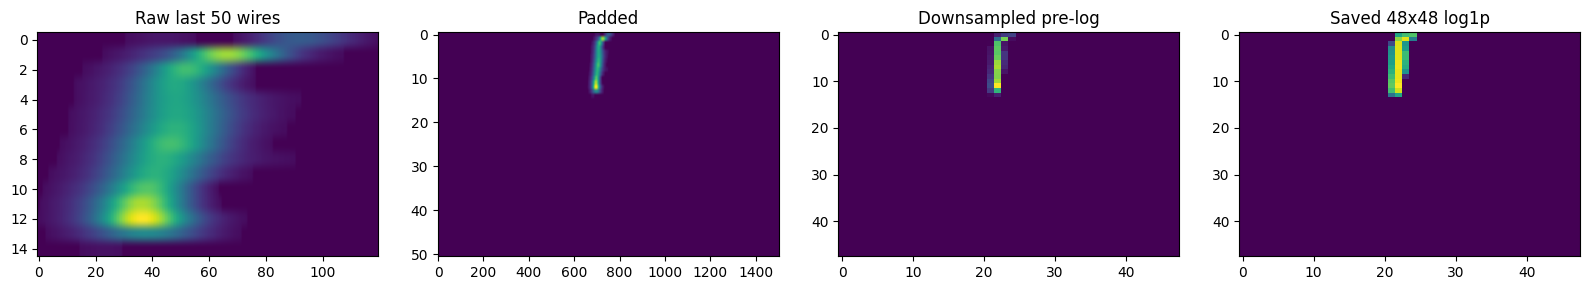

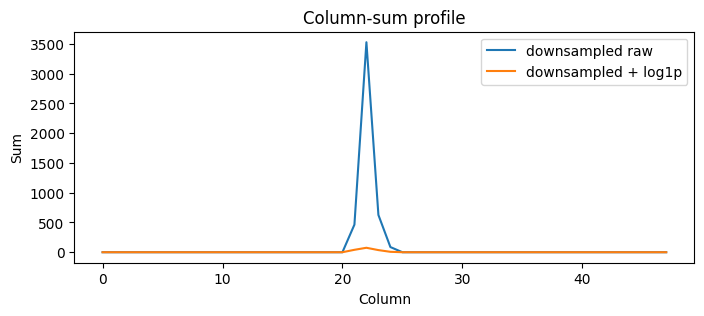

In [8]:
i = 0

end, padded, down_raw = preprocess_before_log(p_c_list[i])
down_log = p_col[i]

fig, axes = plt.subplots(1, 4, figsize=(16, 3))

axes[0].imshow(end, aspect="auto", cmap="viridis")
axes[0].set_title("Raw last 50 wires")

axes[1].imshow(padded, aspect="auto", cmap="viridis")
axes[1].set_title("Padded")

axes[2].imshow(down_raw, aspect="auto", cmap="viridis")
axes[2].set_title("Downsampled pre-log")

axes[3].imshow(down_log, aspect="auto", cmap="viridis")
axes[3].set_title("Saved 48x48 log1p")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(down_raw.sum(axis=0), label="downsampled raw")
plt.plot(down_log.sum(axis=0), label="downsampled + log1p")
plt.legend()
plt.title("Column-sum profile")
plt.xlabel("Column")
plt.ylabel("Sum")
plt.show()
